In [6]:
# =========================
# 0. SETUP
# =========================
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)

from pygam import LogisticGAM, s, l

warnings.filterwarnings("ignore")

DATA_FILE = "../../data/processed/cardio_onc_prostate_04cleaned.csv"
TARGET = "at_risk"
SEED = 42
OUT_DIR = "Results/GAM"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 1. LOAD DATA (FIXED)
# =========================
df = pd.read_csv(DATA_FILE)
df = df[df[TARGET].notna()].copy()

continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features

# sanity check AFTER df exists
missing_cols = [c for c in all_features if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

print(f"Features: {len(all_features)}")

# =========================
# 2. BUILD MATRIX (FULL MODEL USES ALL VARIABLES)
# =========================
X_df = df[all_features].astype(float)
y = df[TARGET].astype(int).values

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X_df)

feature_names = X_df.columns.tolist()

# =========================
# 3. SPLIT
# =========================
def split_data(X, y):
    return train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=SEED
    )

# =========================
# 4. METRICS
# =========================
def compute_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred)
    }

# =========================
# 5. GAM MODEL
# =========================
def build_gam(X, n_cont, lam=0.6):
    terms = s(0)
    for i in range(1, n_cont):
        terms += s(i)
    for i in range(n_cont, X.shape[1]):
        terms += l(i)

    return LogisticGAM(terms, lam=lam)

# =========================
# 6. PARTIAL R2
# =========================
def partial_r2_feature_importance(X, y, n_cont, lam=0.6):
    full_model = build_gam(X, n_cont, lam).fit(X, y)
    full_ll = full_model.loglikelihood(X, y)

    results = []

    for j in range(X.shape[1]):
        mask = [i for i in range(X.shape[1]) if i != j]
        X_red = X[:, mask]

        idx_map = {old: new for new, old in enumerate(mask)}

        first = next((i for i in range(n_cont) if i in mask), None)

        if first is not None:
            terms = s(idx_map[first])
            for i in range(n_cont):
                if i in mask and i != first:
                    terms += s(idx_map[i])
            for i in range(n_cont, X.shape[1]):
                if i in mask:
                    terms += l(idx_map[i])
        else:
            terms = l(idx_map[n_cont])

        model = LogisticGAM(terms, lam=lam).fit(X_red, y)
        ll = model.loglikelihood(X_red, y)

        results.append(1 - (full_ll / ll))

    return np.array(results)

# =========================
# 7. TRAIN FULL MODEL (ALL VARIABLES)
# =========================
X_train, X_test, y_train, y_test = split_data(X, y)

n_cont = len(continuous_features)

full_gam = build_gam(X_train, n_cont).fit(X_train, y_train)

proba_full = full_gam.predict_proba(X_test)
metrics_full = compute_metrics(y_test, proba_full)

# =========================
# 8. FEATURE SELECTION
# =========================
partial_r2 = partial_r2_feature_importance(X_train, y_train, n_cont)

partial_r2_df = pd.DataFrame({
    "feature": feature_names,
    "partial_r2": partial_r2
}).sort_values("partial_r2", ascending=False)

useful_features = partial_r2_df.query("partial_r2 > 0")["feature"].tolist()

# IMPORTANT FIX: reuse imputer consistently
X_red_df = df[useful_features].astype(float)
X_red = imputer.fit_transform(X_red_df)

Xr_train, Xr_test, yr_train, yr_test = split_data(X_red, y)

n_cont_red = sum(f in continuous_features for f in useful_features)

reduced_gam = build_gam(Xr_train, n_cont_red).fit(Xr_train, yr_train)

proba_red = reduced_gam.predict_proba(Xr_test)
metrics_red = compute_metrics(yr_test, proba_red)

# =========================
# 9. SAVE OUTPUTS
# =========================
GAM_DIR = "Results/GAM"
os.makedirs(GAM_DIR, exist_ok=True)

with open(os.path.join(GAM_DIR, "metrics_full.json"), "w") as f:
    json.dump(metrics_full, f, indent=4)

with open(os.path.join(GAM_DIR, "metrics_reduced.json"), "w") as f:
    json.dump(metrics_red, f, indent=4)

partial_r2_df.to_csv(os.path.join(GAM_DIR, "partial_r2.csv"), index=False)

gam_perf = pd.DataFrame([{
    "model": "GAM",
    **metrics_full
}])

print("✔ GAM pipeline fixed + FULL model uses all variables")

Features: 44
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
✔ GAM pipeline fixed + FULL model uses all variables


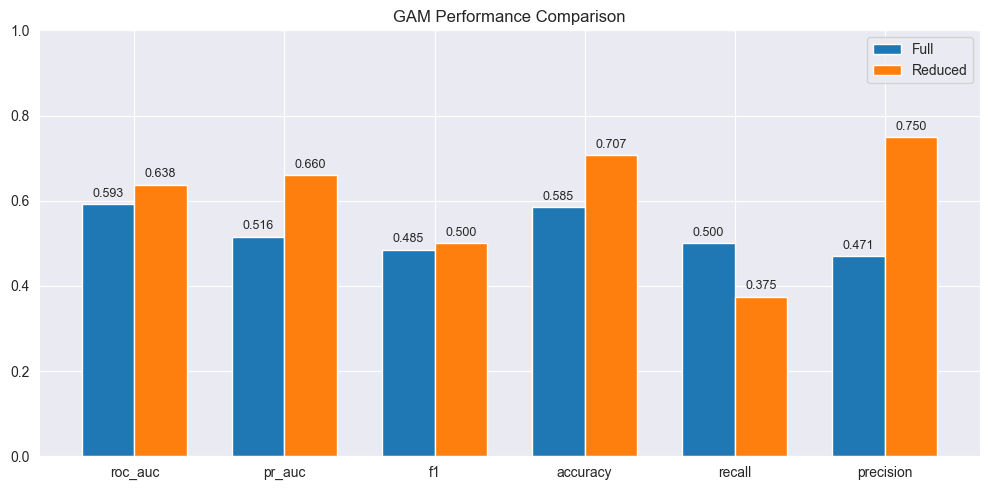

In [7]:
def plot_metrics(metrics_full, metrics_red):
    keys = ["roc_auc", "pr_auc", "f1", "accuracy", "recall", "precision"]

    x = np.arange(len(keys))
    w = 0.35

    plt.figure(figsize=(10, 5))

    bars1 = plt.bar(x - w/2, [metrics_full[k] for k in keys], w, label="Full")
    bars2 = plt.bar(x + w/2, [metrics_red[k] for k in keys], w, label="Reduced")

    # =========================
    # ADD VALUE LABELS
    # =========================
    def add_labels(bars):
        for b in bars:
            height = b.get_height()
            plt.text(
                b.get_x() + b.get_width()/2,
                height + 0.01,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    add_labels(bars1)
    add_labels(bars2)

    plt.xticks(x, keys)
    plt.ylim(0, 1)
    plt.legend()
    plt.title("GAM Performance Comparison")

    plt.tight_layout()
    plt.show()


plot_metrics(metrics_full, metrics_red)

In [8]:
def plot_roc(y_true_f, p_f, y_true_r, p_r):
    fpr_f, tpr_f, _ = roc_curve(y_true_f, p_f)
    fpr_r, tpr_r, _ = roc_curve(y_true_r, p_r)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_f, tpr_f, label="Full")
    plt.plot(fpr_r, tpr_r, label="Reduced")
    plt.plot([0,1],[0,1],"--")
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

In [9]:
# =============================
# 4. GAM (UPDATED + SAVED OUTPUTS)
# =============================

import json

GAM_DIR = "Results/GAM"
os.makedirs(GAM_DIR, exist_ok=True)

GAM_METRICS_PATH = os.path.join(GAM_DIR, "metrics.json")
GAM_IMPORTANCE_PATH = os.path.join(GAM_DIR, "partial_r2.csv")
GAM_REDUCED_METRICS_PATH = os.path.join(GAM_DIR, "reduced_metrics.json")

# =========================
# SAVE FULL MODEL METRICS
# =========================

gam_full_metrics = metrics_full

with open(GAM_METRICS_PATH, "w") as f:
    json.dump(gam_full_metrics, f, indent=4)

# =========================
# SAVE REDUCED MODEL METRICS
# =========================

gam_reduced_metrics = metrics_red

with open(GAM_REDUCED_METRICS_PATH, "w") as f:
    json.dump(gam_reduced_metrics, f, indent=4)

# =========================
# FEATURE IMPORTANCE (partial R²)
# =========================

partial_r2_df.to_csv(GAM_IMPORTANCE_PATH, index=False)

# =========================
# LOAD FOR COMPARISON PIPELINE
# =========================

gam_perf = pd.DataFrame([{
    "model": "GAM",
    "roc_auc": gam_full_metrics["roc_auc"],
    "pr_auc": gam_full_metrics["pr_auc"],
    "f1": gam_full_metrics["f1"],
    "accuracy": gam_full_metrics["accuracy"],
    "recall": gam_full_metrics["recall"],
    "precision": gam_full_metrics["precision"],
}])

print(f"Saved GAM metrics → {GAM_METRICS_PATH}")
print(f"Saved GAM reduced metrics → {GAM_REDUCED_METRICS_PATH}")
print(f"Saved GAM feature importance → {GAM_IMPORTANCE_PATH}")

Saved GAM metrics → Results/GAM/metrics.json
Saved GAM reduced metrics → Results/GAM/reduced_metrics.json
Saved GAM feature importance → Results/GAM/partial_r2.csv


In [10]:
# =========================
# SAVE GAM "COEFFICIENTS" (STANDARDIZED IMPORTANCE TABLE)
# =========================

# 1. Absolute effect size (best analogue to coefficient magnitude)
gam_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": np.abs(partial_r2),
    "signed_effect": partial_r2,
    "type": "partial_r2"
})

# 2. Optional: normalize so comparisons across models are fair
gam_coef["coefficient_normalized"] = (
    gam_coef["coefficient"] / gam_coef["coefficient"].sum()
)

# 3. Save full table
gam_coef.to_csv(
    os.path.join(GAM_DIR, "gam_coefficients.csv"),
    index=False
)

print(f"✔ Saved GAM coefficients → {GAM_DIR}/gam_coefficients.csv")

✔ Saved GAM coefficients → Results/GAM/gam_coefficients.csv
